# Stuart–Landau dynamical order-coordinate benchmark

The original Matthews–Strogatz population is

$$
\dot z_j=(1-|z_j|^2+i\omega_j)z_j+K(Z-z_j),\qquad
Z=N^{-1}\sum_jz_j,\qquad R=|Z|.
$$

Frequencies are evenly spaced on $[-\gamma,\gamma]$ in the rotating frame. We fix $K=0.8$ and vary $\gamma$: this is the published Fig. 1 intercept, illustrating locking, large oscillations, irregular order-parameter motion and incoherence at $\gamma=0.6,0.8,1.0,1.2$. The physical scalar is the future-window mean $Q=\langle R\rangle_t$; temporal SD of $R$ and mean oscillator activity are secondary physical coordinates. The complete 289-SPI p90 catalogue enters the SPI–SPI construction.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
from src.corpus_visualization import plot_mts_heatmap
from src.generators.order_parameter import generate_stuart_landau

RESULTS = ROOT / "data/order_parameter/stuart_landau_development_analysis"
summary = json.loads((RESULTS / "summary.json").read_text())
scores = pd.read_csv(RESULTS / "scores.csv")
CONFIRMATION = ROOT / "data/order_parameter/stuart_landau_confirmation_analysis"
JOINT_GATE = ROOT / "data/order_parameter/stuart_landau_confirmation_joint_gate"
confirmation_available = (CONFIRMATION / "summary.json").exists()
joint_gate_available = (JOINT_GATE / "eligibility_pre_outcome.json").exists()
if confirmation_available:
    confirmation_summary = json.loads((CONFIRMATION / "summary.json").read_text())
    confirmation_eligibility = json.loads((CONFIRMATION / "eligibility_pre_outcome.json").read_text())
    confirmation_scores = pd.read_csv(CONFIRMATION / "scores.csv")
sns.set_theme(style="whitegrid", context="notebook")
print(
    f"rows={summary['rows']}; catalogue={summary['spi_count']} SPIs / "
    f"{summary['meta_feature_count']:,} pairs; retained="
    f"{summary['selected_meta_feature_count']:,}; "
    f"represented SPIs={summary['represented_spi_count']}"
)
print("independent confirmation available:", confirmation_available)

rows=1440; catalogue=289 SPIs / 41,616 pairs; retained=24,466; represented SPIs=234
independent confirmation available: True


## Brief physical orientation

The heatmaps use the same per-process median/robust-scale `icefire` display rule as the corpus-geometry notebook. They establish context; they are not inferential evidence.

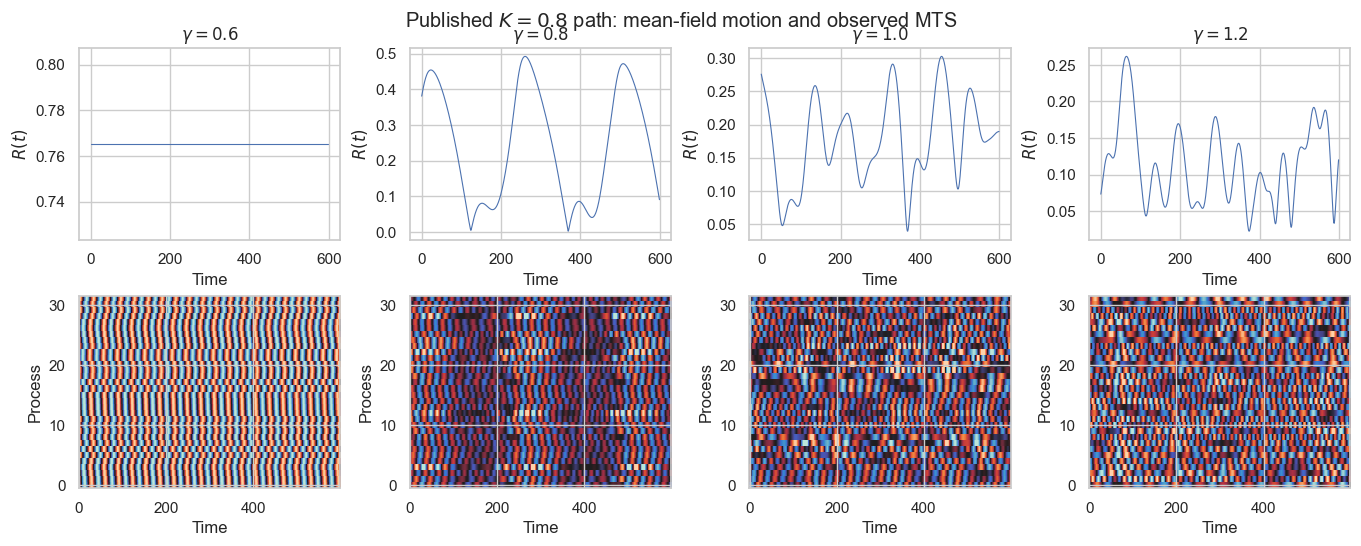

In [2]:
gammas = [0.6, 0.8, 1.0, 1.2]
fig, axes = plt.subplots(2, 4, figsize=(13.5, 5.2), constrained_layout=True)
for column, gamma in enumerate(gammas):
    mts, internals = generate_stuart_landau(
        M=32, T=600, coupling=.8, frequency_half_width=gamma,
        N_full=32, omega_mean=2.0, dt=.02, sample_dt=.1,
        burn_time=200, future_truth_T=0, output="real",
        rng=np.random.default_rng(4100 + column), zscore=False,
        return_internals=True,
    )
    axes[0, column].plot(np.abs(internals.order_parameter), color="C0", lw=.8)
    axes[0, column].set(title=fr"$\gamma={gamma}$", xlabel="Time", ylabel=r"$R(t)$")
    plot_mts_heatmap(mts, method="robust", ax=axes[1, column], colorbar=False)
fig.suptitle(r"Published $K=0.8$ path: mean-field motion and observed MTS", y=1.02)
plt.show()

## Leakage-controlled development assay

The feature-validity gate, imputation, centring and PCA use only full-observation rows with $T\ge500$ and instances 0–3. Neither $\gamma$ nor any physical target enters those fits. Instances 4–7 are the internal held-seed check. $T=100$ is applied after fitting as a stress cell. This remains development analysis; a later bank with new seeds and interleaved controls is the independent confirmation.

## Independent confirmation

The confirmation bank uses eight new seeds and nine interleaved $\gamma$ values. The frozen feature schema, mask, imputation, centre, scale and PC1 are applied before any confirmation target is read. The original joint full/partial gate stopped before outcome access because 14 of 1,296 secondary partial-observation rows exceeded 5% selected-feature missingness. All 648 primary full-observation rows passed the same gate, so the figures below are explicitly an arm-specific confirmation after the global gate failure. Numerical $q\mapsto\widehat Q$ and control-only readouts remain supervised and separate.

original joint-bank eligibility: ineligible {'all_coordinates_finite': True, 'complete_confirmation_design': True, 'homogeneous_clean_provenance': True, 'schema_matches_frozen_model': True, 'selected_missingness_within_gate': False, 'spi_order_matches_frozen_model': True}


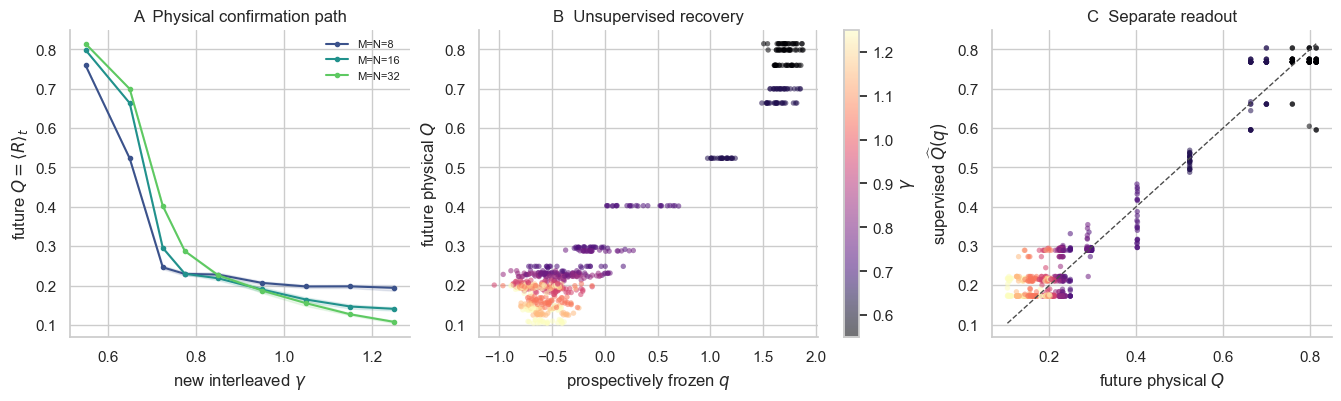

,quantity,value
0,eligible before target read,True
1,overall rho,0.748499
2,overall 95% CI,"[0.7355930019117028, 0.7606903324507147]"
3,within-gamma rho,0.330598
4,pooled gamma-mean rho,1.0
5,q readout MAE,0.040711
6,control-only MAE,0.033445
7,max selected missingness,0.026608


,overall_spearman,supervised_isotonic_mae,within_gamma_spearman
analytic_phase_coherence,0.930,0.019,0.752
mean_abs_correlation,0.904,0.031,0.380
temporal_spectral_entropy,-0.560,0.067,0.051


In [3]:
if not confirmation_available:
    print("Confirmation results are not yet present.")
else:
    if joint_gate_available:
        joint_gate = json.loads((JOINT_GATE / "eligibility_pre_outcome.json").read_text())
        print("original joint-bank eligibility:", joint_gate["status"], joint_gate["gates"])
    confirmed = confirmation_scores.query("arm == 'full'").copy()
    physical_confirmed = confirmed.query("T == 1000")
    fig, axes = plt.subplots(1, 3, figsize=(13.3, 3.9), constrained_layout=True)
    palette_confirm = dict(zip([8, 16, 32], sns.color_palette("viridis", 3)))
    for M, group in physical_confirmed.groupby("M"):
        curve = group.groupby("gamma").Q_R_mean.agg(["mean", "std"]).reset_index()
        axes[0].fill_between(curve.gamma, curve["mean"]-curve["std"], curve["mean"]+curve["std"], color=palette_confirm[M], alpha=.12)
        axes[0].plot(curve.gamma, curve["mean"], "-o", ms=3, color=palette_confirm[M], label=f"M=N={M}")
    axes[0].set(xlabel=r"new interleaved $\gamma$", ylabel=r"future $Q=\langle R\rangle_t$", title="A  Physical confirmation path")
    axes[0].legend(frameon=False, fontsize=8)
    p = axes[1].scatter(confirmed.q, confirmed.Q_R_mean, c=confirmed.gamma, cmap="magma", s=15, alpha=.55, linewidth=0)
    fig.colorbar(p, ax=axes[1], label=r"$\gamma$")
    axes[1].set(xlabel=r"prospectively frozen $q$", ylabel=r"future physical $Q$", title="B  Unsupervised recovery")
    axes[2].scatter(confirmed.Q_R_mean, confirmed.Q_hat_q, c=confirmed.gamma, cmap="magma", s=15, alpha=.55, linewidth=0)
    limits = [confirmed.Q_R_mean.min(), confirmed.Q_R_mean.max()]
    axes[2].plot(limits, limits, color=".3", ls="--", lw=1)
    axes[2].set(xlabel=r"future physical $Q$", ylabel=r"supervised $\widehat Q(q)$", title="C  Separate readout")
    sns.despine(fig)
    plt.show()
    display(pd.DataFrame({
        "quantity": ["eligible before target read", "overall rho", "overall 95% CI", "within-gamma rho", "pooled gamma-mean rho", "q readout MAE", "control-only MAE", "max selected missingness"],
        "value": [confirmation_eligibility["status"] == "eligible", confirmation_summary["full_association"]["overall_spearman"], confirmation_summary["full_association"]["overall_ci95"], confirmation_summary["full_association"]["within_gamma_spearman"], confirmation_summary["full_pooled_gamma_mean_spearman"], confirmation_summary["supervised_q_readout"]["mae"], confirmation_summary["control_only_readout"]["mae"], confirmation_summary["maximum_selected_missingness"]],
    }))
    display(pd.DataFrame(confirmation_summary["input_baselines"]).T.round(3))

## Development and M/T robustness

The following panels are development evidence, retained to diagnose sample length, observation size and source stability.

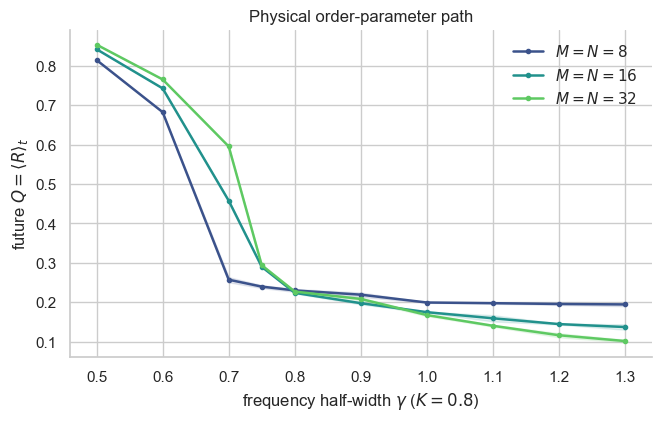

In [4]:
held = scores.query("instance >= 4").copy()
held_full = held.query("arm == 'full'").copy()
physical = held_full.query("T == 1000")

fig, ax = plt.subplots(figsize=(6.5, 4.1), constrained_layout=True)
palette = dict(zip([8, 16, 32], sns.color_palette("viridis", 3)))
for M, group in physical.groupby("M"):
    curve = group.groupby("gamma").Q_R_mean.agg(["mean", "std"]).reset_index()
    ax.fill_between(curve.gamma, curve["mean"]-curve["std"], curve["mean"]+curve["std"], color=palette[M], alpha=.12)
    ax.plot(curve.gamma, curve["mean"], "-o", ms=3, lw=1.8, color=palette[M], label=fr"$M=N={M}$")
ax.set(xlabel=r"frequency half-width $\gamma$ ($K=0.8$)", ylabel=r"future $Q=\langle R\rangle_t$", title="Physical order-parameter path")
ax.legend(frameon=False)
sns.despine(fig)
plt.show()

## One frozen $q$ across $M$ and $T$

PC1 sign is arbitrary and is oriented only for readable display after the target-blind fit. Faint lines are held instances; coloured lines are cell means. Every panel uses the same frozen feature mask, centre and loading. The dashed physical curves are standardized only for visual overlay.

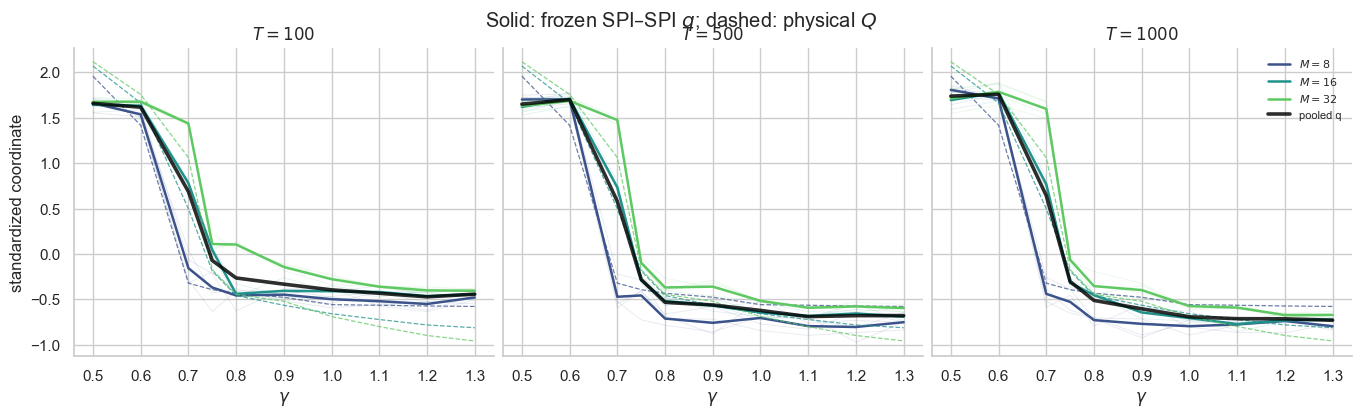

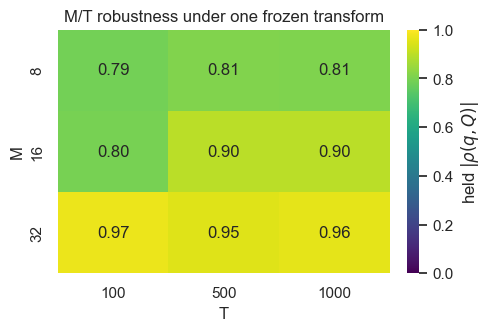

In [5]:
Q_mean = held_full.Q_R_mean.mean()
Q_sd = held_full.Q_R_mean.std()
held_full["Qz"] = (held_full.Q_R_mean - Q_mean) / Q_sd
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9), sharey=True, constrained_layout=True)
for ax, T in zip(axes, [100, 500, 1000]):
    panel = held_full.query("T == @T")
    for M, group in panel.groupby("M"):
        for _, line in group.groupby("instance"):
            line = line.sort_values("gamma")
            ax.plot(line.gamma, line.q, color=palette[M], alpha=.12, lw=.65)
        curve = group.groupby("gamma")[["q", "Qz"]].mean().reset_index()
        ax.plot(curve.gamma, curve.q, color=palette[M], lw=1.8, label=fr"$M={M}$")
        ax.plot(curve.gamma, curve.Qz, color=palette[M], lw=.9, ls="--", alpha=.75)
    pooled = panel.groupby("gamma").q.mean()
    ax.plot(pooled.index, pooled.values, color="black", lw=2.6, alpha=.82, label="pooled q")
    ax.set(title=fr"$T={T}$", xlabel=r"$\gamma$")
axes[0].set_ylabel("standardized coordinate")
axes[-1].legend(frameon=False, fontsize=8)
fig.suptitle(r"Solid: frozen SPI–SPI $q$; dashed: physical $Q$", y=1.03)
sns.despine(fig)
plt.show()

cells = pd.DataFrame(summary["held_full_cell_summary"])
heat = cells.pivot(index="M", columns="T", values="overall_spearman").abs()
fig, ax = plt.subplots(figsize=(4.8, 3.2), constrained_layout=True)
sns.heatmap(heat, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", ax=ax, cbar_kws={"label": r"held $|\rho(q,Q)|$"})
ax.set_title("M/T robustness under one frozen transform")
plt.show()

## Held-seed coordinate recovery and separate numerical inference

The left plot evaluates the unsupervised coordinate. The right plot is explicitly supervised: an isotonic map $q\mapsto\widehat Q$ is fitted on the representation-development rows and applied to held seeds.

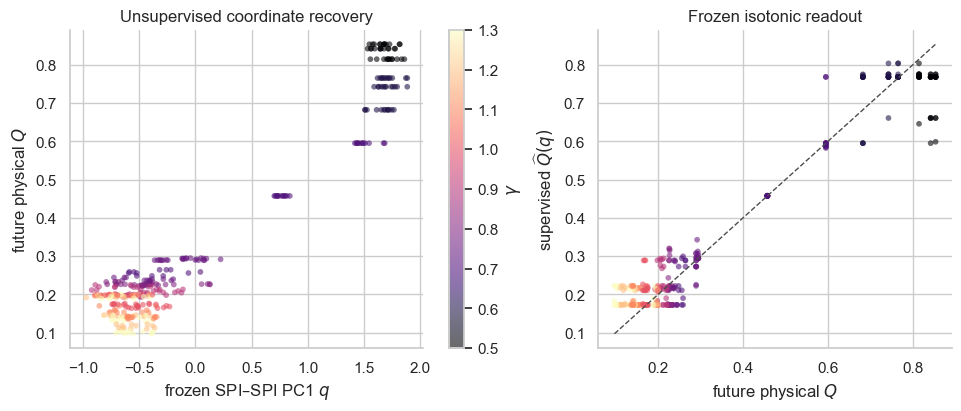

,quantity,value
0,PC1 variance,0.661
1,held full overall rho,0.756
2,held full within-gamma rho,0.157
3,held partial overall rho,0.915
4,held partial within-gamma rho,0.031
5,held full isotonic MAE,0.042


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0), constrained_layout=True)
points = axes[0].scatter(held_full.q, held_full.Q_R_mean, c=held_full.gamma, cmap="magma", s=17, alpha=.58, linewidth=0)
fig.colorbar(points, ax=axes[0], label=r"$\gamma$")
axes[0].set(xlabel=r"frozen SPI–SPI PC1 $q$", ylabel=r"future physical $Q$", title="Unsupervised coordinate recovery")
axes[1].scatter(held_full.Q_R_mean, held_full.Q_hat, c=held_full.gamma, cmap="magma", s=17, alpha=.58, linewidth=0)
limits = [held_full.Q_R_mean.min(), held_full.Q_R_mean.max()]
axes[1].plot(limits, limits, color=".3", ls="--", lw=1)
axes[1].set(xlabel=r"future physical $Q$", ylabel=r"supervised $\widehat Q(q)$", title="Frozen isotonic readout")
sns.despine(fig)
plt.show()

display(pd.DataFrame({
    "quantity": ["PC1 variance", "held full overall rho", "held full within-gamma rho", "held partial overall rho", "held partial within-gamma rho", "held full isotonic MAE"],
    "value": [summary["pc_explained_variance_ratio"][0], summary["held_full_association"]["overall_spearman"], summary["held_full_association"]["within_gamma_spearman"], summary["held_partial_association"]["overall_spearman"], summary["held_partial_association"]["within_gamma_spearman"], summary["held_full_supervised_isotonic_mae"]],
}).round(3))

## Stability, baselines and exploratory alternatives

Choosing the PC that maximizes correlation with $Q$ remains supervised researcher selection even when automated. The oracle table is therefore diagnostic only; PC1 is the predeclared target-blind scalar.

In [7]:
display(pd.DataFrame(summary["target_free_source_stability"]).round(3))
display(pd.DataFrame(summary["exploratory_oracle_pc"]).round(3))
display(pd.DataFrame(summary["held_full_input_baselines"]).T.round(3))

,M,T,explained_variance_ratio,loading_cosine,n
0,8,500,0.601,0.977,40
1,8,1000,0.668,0.982,40
2,16,500,0.685,0.986,40
3,16,1000,0.730,0.987,40
4,32,500,0.778,0.978,40
5,32,1000,0.778,0.982,40


,component,explained_variance_ratio,held_seed_abs_spearman
0,1,0.661,0.756
1,2,0.059,0.192
2,3,0.041,0.088
3,4,0.027,0.373
4,5,0.016,0.346
5,6,0.015,0.333
6,7,0.014,0.038
7,8,0.010,0.011
8,9,0.009,0.037
9,10,0.008,0.002


,overall_spearman,within_gamma_spearman
analytic_phase_coherence,0.932,0.779
mean_abs_correlation,0.909,0.325
temporal_spectral_entropy,-0.586,-0.216
